# Callable Bond Pricing under Longstaff-Schwartz Monte Carlo
## Bridging Module 2 Binomial Tree with Module 3 Simulation

Module 2 (`09_callable_bonds.ipynb`) priced a callable bond using a **binomial tree**. That approach is exact for one-factor models on a single bond, but it does not scale: pricing a portfolio of callables under thousands of Monte Carlo scenarios (as XVA requires) demands a simulation-based method.

**Longstaff-Schwartz (LSM)** (Longstaff & Schwartz, 2001) solves this by estimating the **continuation value** at each exercise date via a least-squares regression of simulated future cashflows onto basis functions of the current state. The key insight: you do not need the true conditional expectation — an estimate good enough to make the right exercise decision is sufficient.

---

**Callable bond structure:**

A callable bond gives the **issuer** the right (not obligation) to redeem the bond before maturity at a pre-agreed **call price** $K$. The issuer exercises optimally — calling when the bond is trading above $K$ (i.e., when it is cheaper to retire and refinance).

$$V_{\text{callable}} = V_{\text{straight}} - V_{\text{call option}}$$

The embedded call option has positive value to the issuer (negative to the holder), so a callable bond always trades below the equivalent straight bond.

---

**Regulatory context — IRRBB:**

Under EBA/RTS/2022/10, banks holding callable structured notes in their banking book must model the embedded optionality when computing EVE SOT. A callable bond's duration changes non-linearly with rates (negative convexity) — the extension/contraction risk under the prescribed EBA shocks must be captured in the repricing schedule. LSM provides the simulation-based valuation framework for this.

---

**Structure**
1. Setup — bond parameters, straight bond benchmark
2. The LSM algorithm — backwards induction with regression
3. Implementation from scratch — step by step
4. Call option value decomposition
5. Convergence vs path count and basis function choice
6. Comparison to QuantLib binomial tree

In [1]:
from scipy import stats
import QuantLib as ql

from quant_risk.setup import base
np, pd, plt = base()

from quant_risk.config import PROCESSED_DIR
from quant_risk.curves.ois import OISCurve
from quant_risk.models.rates import VasicekProcess

RNG_SEED = 42

base loaded


In [2]:
# ── Model and bond parameters ─────────────────────────────────────────────────
# Vasicek short rate model
kappa = 0.10    # mean reversion speed
theta = 2.50    # long-run mean (percent)
sigma = 0.80    # volatility — slightly higher than QRE-49 to make the call option valuable
r0    = 2.50    # initial short rate (percent)

vasicek = VasicekProcess(kappa=kappa, theta=theta, sigma=sigma)
print(vasicek.describe())

# Callable bond terms
face_value  = 100.0    # EUR
coupon_rate = 4.00     # percent — above the current rate, making calls likely
coupon      = face_value * coupon_rate / 100   # EUR per year
call_price  = 100.0    # par call (most common)
T_bond      = 5.0      # maturity in years
call_start  = 1        # first call date (year 1)
call_dates  = list(range(call_start, int(T_bond)))   # call dates at years 1, 2, 3, 4

# Monthly simulation steps — 12 per year, 60 total
N_PER_YEAR = 12
N_STEPS    = N_PER_YEAR * int(T_bond)   # 60 steps
DT         = T_bond / N_STEPS           # 1/12 year per step

print(f"\nCallable bond: {coupon_rate}% coupon, {T_bond}Y maturity, call at par from year {call_start}")
print(f"Call dates: years {call_dates}")
print(f"Simulation: {N_STEPS} steps × {DT:.4f}Y/step = {T_bond}Y")

Vasicek | κ=0.1000 | θ=2.50% | σ=0.8000%/√yr

Callable bond: 4.0% coupon, 5.0Y maturity, call at par from year 1
Call dates: years [1, 2, 3, 4]
Simulation: 60 steps × 0.0833Y/step = 5.0Y


---
## 1. Straight Bond Benchmark

Before pricing the callable, we establish the **straight bond price** — the value without any embedded option. This is the upper bound for the callable bond price.

Under the Vasicek model, the straight bond price is:

$$V_{\text{straight}} = c \sum_{k=1}^N P^{\text{Vas}}(0, T_k) + F \cdot P^{\text{Vas}}(0, T_N)$$

where $P^{\text{Vas}}(0, T)$ is the analytical Vasicek ZCB price (derived in QRE-49) and $c = F \times r_{\text{coupon}}$ is the annual coupon.

In [3]:
# ── Analytical Vasicek ZCB price (from QRE-49) ────────────────────────────────
def vasicek_zcb(T, r0, kappa, theta, sigma):
    """Analytical Vasicek zero-coupon bond price. All rates in percent."""
    r0_d, theta_d, sigma_d = r0/100, theta/100, sigma/100
    B    = (1 - np.exp(-kappa * T)) / kappa
    ln_A = ((B - T) * (kappa**2 * theta_d - 0.5 * sigma_d**2) / kappa**2
            - sigma_d**2 * B**2 / (4 * kappa))
    return np.exp(ln_A - B * r0_d)

# Straight bond price (analytical)
coupon_dates = list(range(1, int(T_bond) + 1))   # years 1, 2, 3, 4, 5
V_straight_ana = sum(
    coupon * vasicek_zcb(T_k, r0, kappa, theta, sigma)
    for T_k in coupon_dates
) + face_value * vasicek_zcb(T_bond, r0, kappa, theta, sigma)

print("Straight bond — Vasicek analytical valuation:")
print(f"{'Year':>6}  {'Cashflow':>10}  {'P(0,T)':>12}  {'PV':>10}")
print("-" * 44)
for T_k in coupon_dates:
    cf   = coupon + (face_value if T_k == int(T_bond) else 0)
    p_t  = vasicek_zcb(T_k, r0, kappa, theta, sigma)
    print(f"{T_k:>6.0f}  {cf:>10.2f}  {p_t:>12.6f}  {cf*p_t:>10.4f}")
print("-" * 44)
print(f"{'Total':>6}  {'':>10}  {'':>12}  {V_straight_ana:>10.4f}")
print()
print(f"Note: bond trades {'above' if V_straight_ana > 100 else 'below'} par "
      f"(coupon {coupon_rate}% vs short rate {r0}%) — "
      f"embedded call is {'in' if V_straight_ana > 100 else 'out of'}-the-money.")

Straight bond — Vasicek analytical valuation:
  Year    Cashflow        P(0,T)          PV
--------------------------------------------
     1        4.00      0.975320      3.9013
     2        4.00      0.951299      3.8052
     3        4.00      0.927958      3.7118
     4        4.00      0.905300      3.6212
     5      104.00      0.883320     91.8652
--------------------------------------------
 Total                              106.9048

Note: bond trades above par (coupon 4.0% vs short rate 2.5%) — embedded call is in-the-money.


---
## 2. The Longstaff-Schwartz Algorithm

### 2.1 Problem Setup

The callable bond can be exercised (called) by the issuer at $t_1, t_2, \ldots, t_{N-1}$. The issuer's optimal strategy is to call whenever the **continuation value** (what the bond would be worth if left outstanding) exceeds the **call price** $K$:

$$\text{Call at } t_k \iff \mathbb{E}^{\mathbb{Q}}\!\left[\frac{B(t_k)}{B(t_{k+1})} V(t_{k+1})\right] > K$$

where $V(t_{k+1})$ is the bond's value just after $t_k$.

### 2.2 Why Not Just Compute the Conditional Expectation Directly?

In general, $\mathbb{E}[V(t_{k+1}) \mid r(t_k)]$ has no closed form under an optimal exercise strategy. The binomial tree approximates it via backward induction on the tree. LSM approximates it via **regression on simulated paths**.

### 2.3 The Three Steps of LSM

**Step 1 — Simulate** $M$ paths of the short rate over the bond's life.

**Step 2 — Backwards induction.** At each call date $t_k$, working from $t_{N-1}$ to $t_1$:

1. Compute the **realised continuation value** for each path:

$$C^\omega(t_k) = V^\omega(t_{k+1}) \cdot D^\omega(t_k, t_{k+1})$$

where $D^\omega(t_k, t_{k+1}) = \exp\!\left(-\int_{t_k}^{t_{k+1}} r^\omega(s)\,ds\right)$ is the path-integral discount factor.

2. **Filter** to in-the-money (ITM) paths — those where calling is potentially beneficial, i.e., $C^\omega(t_k) > K$.

3. **Regress** the realised continuation values of ITM paths onto basis functions $\phi_j(r^\omega(t_k))$:

$$C(t_k) \approx \sum_j \beta_j\,\phi_j(r(t_k)) \qquad \Rightarrow \qquad \hat{C}(t_k) = \boldsymbol{\phi}\,\hat{\boldsymbol{\beta}}$$

4. **Call** on paths where $\hat{C}^\omega(t_k) > K$ (estimated continuation exceeds call price).

5. Update each path's claim: $V^\omega(t_k) = K$ if called, $C^\omega(t_k)$ otherwise. Add coupon $c$ to all paths.

**Step 3 — Price.** Discount all path claims from $t_1$ back to $t_0$:

$$\hat{V}_{\text{callable}} = \frac{1}{M}\sum_\omega V^\omega(t_1) \cdot D^\omega(0, t_1)$$

### 2.4 Basis Functions

Common choices:
<small>

| Basis | Functions |
|---|---|
| Polynomial (degree 2) | $1,\ r,\ r^2$ |
| Polynomial (degree 3) | $1,\ r,\ r^2,\ r^3$ |
| Laguerre (degree 2) | $e^{-r/2},\ e^{-r/2}(1-r),\ e^{-r/2}(1-2r+r^2/2)$ |

</small>

For one-factor short rate models, polynomial degree 2 or 3 is typically sufficient. The regression result is used only to determine the **exercise boundary** — small regression errors matter only if they cause incorrect call decisions near the boundary.

In [4]:
# ── Simulate rate paths ───────────────────────────────────────────────────────
M = 10000   # number of paths — more needed for callable bonds than vanilla

paths = vasicek.simulate(
    x0       = r0,
    T        = T_bond,
    n_steps  = N_STEPS,
    n_paths  = M,
    antithetic = True,    # variance reduction
    seed     = RNG_SEED,
)
# paths shape: (M, N_STEPS + 1)
# paths[:, k] = short rate at month k (in percent)

# Pre-compute cumulative path integral for arbitrary-interval discounting
cum_int = np.cumsum(paths[:, :-1] / 100 * DT, axis=1)  # (M, N_STEPS)
# cum_int[:, k] = ∫_0^{(k+1)·dt} r(s)ds  along each path

def path_sdf(t_start: float, t_end: float) -> np.ndarray:
    """Stochastic discount factor exp(-∫_{t_start}^{t_end} r(s)ds) for each path."""
    i_start = max(int(round(t_start / DT)) - 1, 0)
    i_end   = int(round(t_end   / DT)) - 1
    c_end   = cum_int[:, i_end]
    c_start = cum_int[:, i_start] if i_start >= 0 else np.zeros(M)
    return np.exp(-(c_end - c_start))

print(f"Paths shape: {paths.shape}")
print(f"Rate at t=0 (all paths): {paths[:, 0].mean():.4f}% (= r0 = {r0}%)")
print(f"Rate at t=5 mean:        {paths[:, -1].mean():.4f}%  (≈ θ = {theta}%)")

Paths shape: (10000, 61)
Rate at t=0 (all paths): 2.5000% (= r0 = 2.5%)
Rate at t=5 mean:        2.5000%  (≈ θ = 2.5%)


In [5]:
# ── MC straight bond price — benchmark for LSM ────────────────────────────────
# Sum discounted cashflows at each coupon date along every path
V_mc_straight = np.zeros(M)

for T_k in coupon_dates:
    cf       = coupon + (face_value if T_k == int(T_bond) else 0)
    disc_k   = path_sdf(0.0, T_k)           # discount from t=0 to T_k
    V_mc_straight += cf * disc_k

straight_mc_price = V_mc_straight.mean()
straight_mc_se    = V_mc_straight.std() / np.sqrt(M)

print("Straight bond MC price vs analytical benchmark:")
print(f"  MC price:    {straight_mc_price:.4f}  (SE = {straight_mc_se:.4f})")
print(f"  Analytical:  {V_straight_ana:.4f}")
print(f"  Error:       {abs(straight_mc_price - V_straight_ana):.4f}")

Straight bond MC price vs analytical benchmark:
  MC price:    107.1269  (SE = 0.0419)
  Analytical:  106.9048
  Error:       0.2221


---
## 3. LSM Implementation

We now implement the full LSM algorithm. The key data structure is a **claim vector** `V[m]` for each path $\omega = m$ — the present value of all cashflows the bond holder will receive, updated as we step backwards.

At each call date $t_k$, we:
1. Discount `V` (next period's claim) back by one period to get the continuation value $C$
2. Run OLS on ITM paths to estimate $\hat{C}$
3. Call on paths where $\hat{C} > K$ and update `V`
4. Add the coupon paid at $t_k$ to all paths (regardless of call decision)

In [6]:
# ── LSM callable bond pricing — core implementation ──────────────────────────
def lsm_callable_bond(
    paths:       np.ndarray,
    cum_int:     np.ndarray,
    face:        float,
    coupon:      float,
    call_price:  float,
    call_dates:  list,
    T_bond:      float,
    DT:          float,
    degree:      int = 2,
    verbose:     bool = False,
) -> tuple:
    """
    Price a callable fixed-rate bond via Longstaff-Schwartz Monte Carlo.

    The issuer holds the call option: calls when continuation > call_price.

    Parameters
    ----------
    paths      : (M, N+1) simulated short rate paths in percent
    cum_int    : (M, N) cumulative integral ∫r·dt along each path
    face       : face value (principal)
    coupon     : annual coupon payment in currency units
    call_price : call price (typically par = face)
    call_dates : list of call date years, e.g. [1, 2, 3, 4]
    T_bond     : maturity in years
    DT         : simulation step size in years
    degree     : polynomial degree for the regression basis (1, 2, or 3)
    verbose    : print call statistics at each date

    Returns
    -------
    (bond_price, call_flags) where bond_price is the scalar LSM estimate
    and call_flags is (M,) array: the year at which each path was called
    (0 = not called).
    """
    M = paths.shape[0]

    # --- Initialise at maturity -------------------------------------------------
    # Every path receives face + coupon at maturity (not yet discounted)
    V          = np.full(M, face + coupon, dtype=float)
    not_called = np.ones(M, dtype=bool)   # track which paths have NOT been called
    call_year  = np.zeros(M, dtype=int)   # record when each path is called

    # All call dates in reverse order (backwards induction)
    for t_k in sorted(call_dates, reverse=True):
        t_next = t_k + 1   # next cashflow date

        # Index of the current call date on the simulation grid
        idx_k    = int(round(t_k / DT))
        idx_next = int(round(t_next / DT)) - 1

        # Discount V (claim at t_next) back to t_k along each path:
        # D(t_k → t_next) = exp(-(cum_int[t_next] - cum_int[t_k]))
        c_next    = cum_int[:, idx_next]
        c_k       = cum_int[:, idx_k - 1] if idx_k > 0 else np.zeros(M)
        disc_1    = np.exp(-(c_next - c_k))      # one-period path discount

        # Continuation value at t_k: PV of claim at t_next
        cont      = V * disc_1

        # Only consider paths not yet called by the issuer
        alive     = not_called

        # In-the-money for the issuer: continuation > call_price
        # (bond would cost more to keep than to retire)
        itm       = alive & (cont > call_price)

        if itm.sum() > max(10, degree + 1):
            # ── LSM regression on ITM paths ────────────────────────────────────
            # Basis functions: polynomial in the current short rate r(t_k)
            r_k      = paths[:, idx_k] / 100   # decimal, shape (M,)
            X        = np.column_stack(
                [r_k**j for j in range(degree + 1)]   # [1, r, r², ...]
            )  # (M, degree+1)

            # Fit OLS using only the ITM paths
            beta     = np.linalg.lstsq(X[itm], cont[itm], rcond=None)[0]

            # Predicted continuation value across ALL paths (not just ITM)
            cont_hat = X @ beta

            # Call decision: issuer calls on ITM paths where estimated value > K
            call_now = itm & (cont_hat > call_price)

            # Update claims:
            #   Called paths → receive call_price (principal returned)
            #   Non-called   → continuation value rolls forward
            V = np.where(call_now, call_price, cont)

            # Record call and mark path as no longer alive
            call_year[call_now]  = int(t_k)
            not_called[call_now] = False

            if verbose:
                print(f"  t={t_k:.0f}Y: ITM={itm.sum():>5}  called={call_now.sum():>5}  "
                      f"({call_now.sum()/M*100:.1f}%)")
        else:
            # Too few ITM paths for regression — no calling at this date
            V = cont
            if verbose:
                print(f"  t={t_k:.0f}Y: ITM={itm.sum():>5}  (too few for regression)")

        # Coupon paid at t_k to ALL holders (regardless of call decision)
        V += coupon

    # --- Discount everything back to t=0 ----------------------------------------
    # V now holds the value at t=1 (first coupon/call date); discount to t=0
    disc_to_0  = np.exp(-cum_int[:, int(round(1.0 / DT)) - 1])
    V_at_0     = V * disc_to_0

    return V_at_0.mean(), call_year

# ── Price the callable bond ───────────────────────────────────────────────────
lsm_price, call_year = lsm_callable_bond(
    paths, cum_int, face_value, coupon, call_price,
    call_dates, T_bond, DT, degree=2, verbose=True,
)

print(f"\nLSM callable bond price: {lsm_price:.4f}")
print(f"Straight bond MC price:  {straight_mc_price:.4f}")
print(f"Embedded call option:    {straight_mc_price - lsm_price:.4f}  "
      f"({(straight_mc_price - lsm_price) / straight_mc_price * 100:.2f}% of straight price)")

  t=4Y: ITM= 8546  called= 8496  (85.0%)
  t=3Y: ITM=  342  called=  342  (3.4%)
  t=2Y: ITM=  239  called=  239  (2.4%)
  t=1Y: ITM=  248  called=  248  (2.5%)

LSM callable bond price: 105.4413
Straight bond MC price:  107.1269
Embedded call option:    1.6856  (1.57% of straight price)


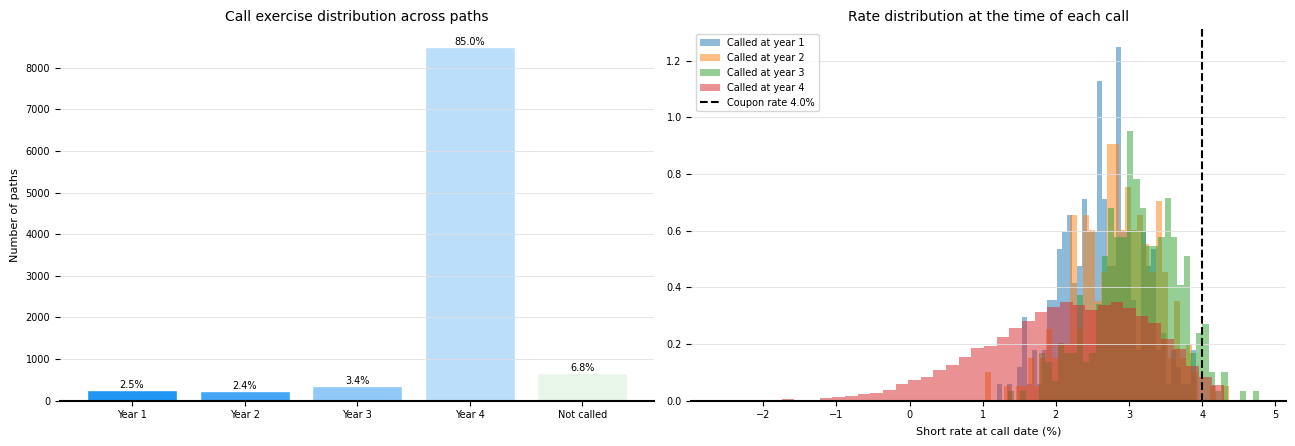


Total paths called: 9,325 / 10,000 (93.2%)

Observation: calls concentrate when rates fall below the coupon rate.
The issuer refinances at the lower market rate — classic negative convexity.


In [ ]:
# ── Call exercise analysis ────────────────────────────────────────────────────
# When does the issuer call, and under what rate scenarios?

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram of call years
ax = ax0
call_years_nonzero = call_year[call_year > 0]
not_called_count   = (call_year == 0).sum()
labels   = [f"Year {k}" for k in call_dates] + ["Not called"]
counts   = [((call_year == k).sum()) for k in call_dates] + [not_called_count]
colors   = ['#2196F3','#42A5F5','#90CAF9','#BBDEFB','#E8F5E9']
ax.bar(labels, counts, color=colors[:len(labels)], edgecolor='white')
ax.set_ylabel("Number of paths")
ax.set_title("Call exercise distribution across paths")
for i, v in enumerate(counts):
    ax.text(i, v + 50, f"{v/M*100:.1f}%", ha='center', fontsize=7)

# Right: rate level at call date by outcome
ax = ax1
for t_k in call_dates:
    idx_k = int(round(t_k / DT))
    called_at_k = call_year == t_k
    if called_at_k.sum() > 0:
        ax.hist(
            paths[called_at_k, idx_k],
            bins=40, alpha=0.5, density=True, label=f"Called at year {t_k}"
        )

ax.axvline(coupon_rate, lw=1.5, color='black', ls='--', label=f"Coupon rate {coupon_rate}%")
ax.set_xlabel("Short rate at call date (%)")
ax.set_title("Rate distribution at the time of each call")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nTotal paths called: {(call_year > 0).sum():,} / {M:,} "
      f"({(call_year > 0).sum()/M*100:.1f}%)")
print("\nObservation: calls concentrate when rates fall below the coupon rate.")
print("The issuer refinances at the lower market rate — classic negative convexity.")

---
## 4. Call Option Value Decomposition

The callable bond price decomposes as:

$$V_{\text{callable}} = V_{\text{straight}} - \underbrace{(V_{\text{straight}} - V_{\text{callable}})}_{\text{call option value}}$$

The call option value is the cost to the bondholder of granting the issuer the right to retire early. It equals the fair value a bondholder would demand as compensation for this feature (the **option-adjusted spread** adjustment).

**Negative convexity:** For a callable bond, when rates fall, the straight bond appreciates but the call option also appreciates (in the issuer's favour). The net effect: the callable bond's price is capped near the call price for low rates — **price compression** — giving the bond negative convexity.

$$\frac{\partial^2 V_{\text{callable}}}{\partial r^2} < \frac{\partial^2 V_{\text{straight}}}{\partial r^2}$$

This is the key risk under IRRBB parallel-down shocks: the repricing schedule of the callable bond shortens when rates fall, reducing EVE sensitivity asymmetrically.

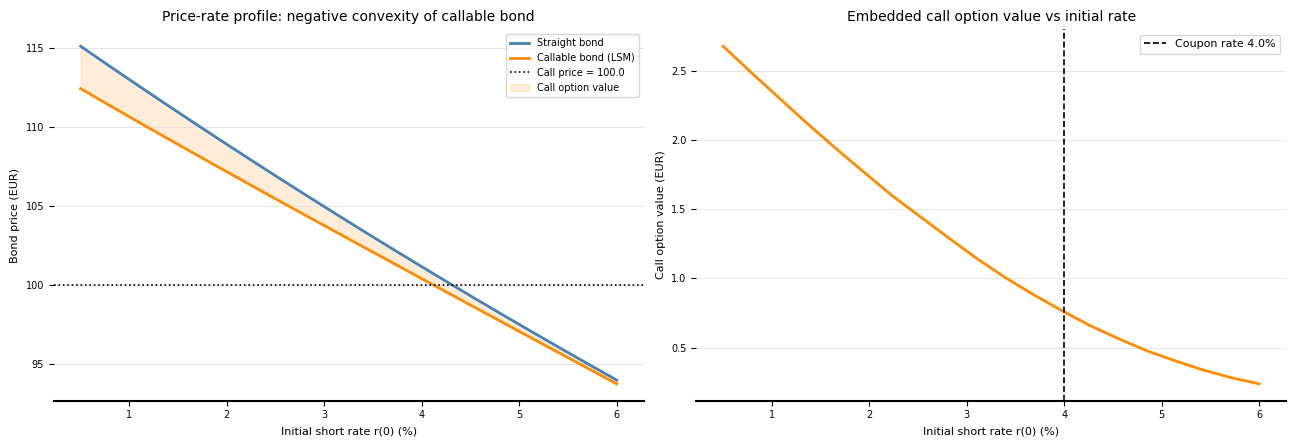

At r(0)=2.5%:  straight=106.8012,  callable=105.3573,  call option=1.4439


In [ ]:
# ── Price-rate profile: callable vs straight (negative convexity) ─────────────
# Compute prices at different initial rate levels by re-running the simulation
# Each run uses a different r0; same random numbers (antithetic, same seed)

r0_grid    = np.linspace(0.5, 6.0, 20)   # initial rates from 0.5% to 6%
prices_str = np.zeros(len(r0_grid))
prices_cal = np.zeros(len(r0_grid))
M_small    = 2000   # smaller M for speed in this loop

for j, r0_j in enumerate(r0_grid):
    # Straight bond: analytical Vasicek sum of ZCBs
    prices_str[j] = sum(
        (coupon + (face_value if T_k == int(T_bond) else 0)) *
        vasicek_zcb(T_k, r0_j, kappa, theta, sigma)
        for T_k in coupon_dates
    )

    # Callable bond: LSM with fresh simulation at r0_j
    p_j = vasicek.simulate(
        x0=r0_j, T=T_bond, n_steps=N_STEPS, n_paths=M_small,
        antithetic=True, seed=RNG_SEED,
    )
    c_j = np.cumsum(p_j[:, :-1] / 100 * DT, axis=1)
    prices_cal[j], _ = lsm_callable_bond(
        p_j, c_j, face_value, coupon, call_price,
        call_dates, T_bond, DT, degree=2,
    )

call_option_value = prices_str - prices_cal

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: price-rate profile
ax = ax0
ax.plot(r0_grid, prices_str, '-',  color='steelblue',  lw=2.0, label="Straight bond")
ax.plot(r0_grid, prices_cal, '-',  color='darkorange', lw=2.0, label="Callable bond (LSM)")
ax.axhline(call_price, lw=1.2, color='black', ls=':', label=f"Call price = {call_price}")
ax.fill_between(r0_grid, prices_cal, prices_str,
                alpha=0.15, color='darkorange', label="Call option value")
ax.set_xlabel("Initial short rate r(0) (%)")
ax.set_ylabel("Bond price (EUR)")
ax.set_title("Price-rate profile: negative convexity of callable bond")
ax.legend(fontsize=7)

# Right: call option value vs rate
ax = ax1
ax.plot(r0_grid, call_option_value, '-', color='darkorange', lw=2.0)
ax.axvline(coupon_rate, lw=1.2, color='black', ls='--',
           label=f"Coupon rate {coupon_rate}%")
ax.set_xlabel("Initial short rate r(0) (%)")
ax.set_ylabel("Call option value (EUR)")
ax.set_title("Embedded call option value vs initial rate")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

idx_r0 = np.argmin(np.abs(r0_grid - r0))
print(f"At r(0)={r0}%:  straight={prices_str[idx_r0]:.4f},  "
      f"callable={prices_cal[idx_r0]:.4f},  "
      f"call option={call_option_value[idx_r0]:.4f}")

---
## 5. Convergence Analysis

### 5.1 Convergence vs Path Count

LSM has two sources of error:
1. **MC sampling noise** — $O(1/\sqrt{M})$, reduced by antithetic variates
2. **Regression bias** — the estimated exercise boundary is suboptimal; this introduces a **downward bias** on the price (we sometimes call sub-optimally, undervaluing the bond holder's claim)

More paths improve the regression estimate, reducing both sources simultaneously.

### 5.2 Basis Function Choice

The regression basis affects accuracy near the exercise boundary. Using too few basis functions biases the exercise decision; too many can overfit to the in-sample paths. For one-dimensional state (single short rate), degree 2 or 3 is standard. We compare:
- **Degree 1**: $\{1, r\}$ — linear, may miss curvature near the boundary
- **Degree 2**: $\{1, r, r^2\}$ — standard choice
- **Degree 3**: $\{1, r, r^2, r^3\}$ — diminishing returns for smooth boundaries

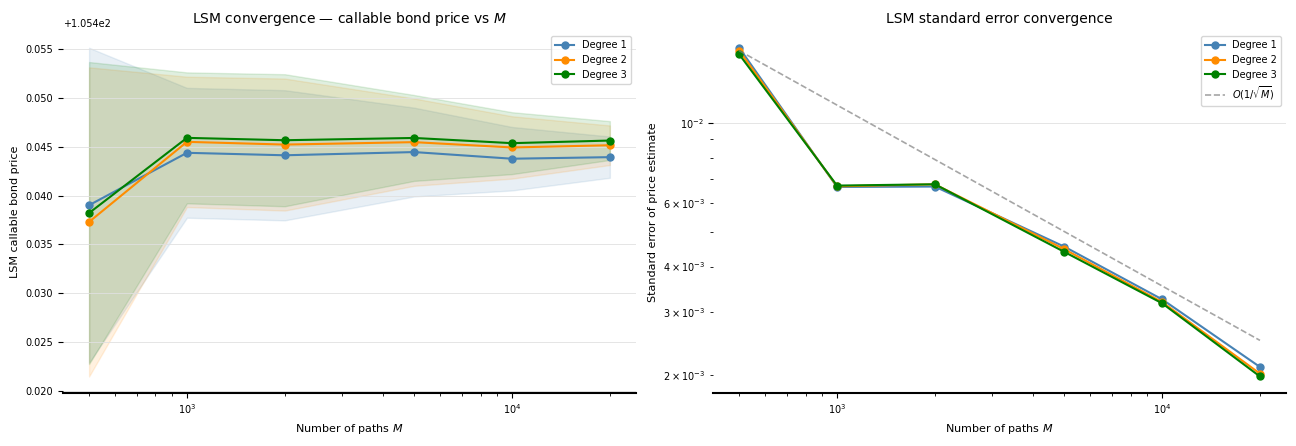


Price estimates at M=20,000 paths:
  Degree 1: 105.4439  (SE = 0.0021)
  Degree 2: 105.4451  (SE = 0.0020)
  Degree 3: 105.4456  (SE = 0.0020)


In [ ]:
# ── Convergence vs path count ─────────────────────────────────────────────────
path_counts = [500, 1000, 2000, 5000, 10000, 20000]
n_trials    = 30    # fewer trials — LSM is expensive

conv_results = {deg: [] for deg in [1, 2, 3]}

for M_j in path_counts:
    for deg in [1, 2, 3]:
        prices_j = []
        for trial in range(n_trials):
            p_t = vasicek.simulate(
                x0=r0, T=T_bond, n_steps=N_STEPS, n_paths=M_j,
                antithetic=True, seed=trial * 100,
            )
            c_t = np.cumsum(p_t[:, :-1] / 100 * DT, axis=1)
            price_t, _ = lsm_callable_bond(
                p_t, c_t, face_value, coupon, call_price,
                call_dates, T_bond, DT, degree=deg,
            )
            prices_j.append(price_t)
        conv_results[deg].append(prices_j)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

colors_deg = {1: 'steelblue', 2: 'darkorange', 3: 'green'}

# Left: mean price vs M for each basis degree
ax = ax0
for deg in [1, 2, 3]:
    means = [np.mean(conv_results[deg][j]) for j in range(len(path_counts))]
    ses   = [np.std(conv_results[deg][j]) for j in range(len(path_counts))]
    ax.semilogx(path_counts, means, 'o-', color=colors_deg[deg],
                lw=1.5, ms=5, label=f"Degree {deg}")
    ax.fill_between(path_counts,
                    [m-s for m,s in zip(means,ses)],
                    [m+s for m,s in zip(means,ses)],
                    alpha=0.12, color=colors_deg[deg])

ax.set_xlabel("Number of paths $M$")
ax.set_ylabel("LSM callable bond price")
ax.set_title("LSM convergence — callable bond price vs $M$")
ax.legend()

# Right: standard error vs M (O(1/√M) convergence)
ax = ax1
for deg in [1, 2, 3]:
    ses = [np.std(conv_results[deg][j]) for j in range(len(path_counts))]
    ax.loglog(path_counts, ses, 'o-', color=colors_deg[deg], lw=1.5, ms=5, label=f"Degree {deg}")

# O(1/√M) reference
se_0 = np.std(conv_results[2][0])
ref  = [se_0 * np.sqrt(path_counts[0] / M_j) for M_j in path_counts]
ax.loglog(path_counts, ref, '--', color='gray', lw=1.2, alpha=0.7, label=r"$O(1/\sqrt{M})$")
ax.set_xlabel("Number of paths $M$")
ax.set_ylabel("Standard error of price estimate")
ax.set_title("LSM standard error convergence")
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print(f"\nPrice estimates at M={path_counts[-1]:,} paths:")
for deg in [1, 2, 3]:
    vals = conv_results[deg][-1]
    print(f"  Degree {deg}: {np.mean(vals):.4f}  (SE = {np.std(vals):.4f})")

---
## 6. Comparison to QuantLib Binomial Tree

QuantLib provides a `CallableFixedRateBond` priced by the `TreeCallableFixedRateBondEngine` using a Hull-White trinomial tree. This is the standard binomial/trinomial-tree approach from Module 2, extended to callable bonds.

For a **flat yield curve at $r_0 = 2.5\%$**, the Hull-White model in QuantLib reduces to Vasicek with the same mean reversion speed and volatility. This gives us a direct comparison between:
- LSM (simulation + regression)
- QuantLib tree (deterministic backwards induction)

Both should converge to the same price as the approximation resolution increases.

In [10]:
# ── QuantLib callable bond — trinomial tree benchmark ────────────────────────
# Build a flat term structure at r0 = 2.5%
settlement = ql.Date(24, 3, 2026)   # match the OIS curve valuation date
ql.Settings.instance().evaluationDate = settlement

r0_dec = r0 / 100   # decimal
flat_ts = ql.YieldTermStructureHandle(
    ql.FlatForward(settlement, r0_dec, ql.Actual365Fixed())
)

# Hull-White model with same κ and σ as our Vasicek simulation
# (reduces to Vasicek for flat initial term structure)
hw_model = ql.HullWhite(flat_ts, kappa, sigma / 100)   # σ in decimal for QL

# Bond schedule: 5Y annual coupon bond
maturity_date = settlement + ql.Period(int(T_bond), ql.Years)
schedule = ql.Schedule(
    settlement, maturity_date, ql.Period(ql.Annual),
    ql.TARGET(), ql.ModifiedFollowing, ql.ModifiedFollowing,
    ql.DateGeneration.Forward, False,
)

# Callability schedule: call at par at years 1, 2, 3, 4
callability = ql.CallabilitySchedule()
for t_k in call_dates:
    call_date_ql = settlement + ql.Period(t_k, ql.Years)
    # Clean call price = par (QuantLib uses clean price in callability)
    ql_call_price = ql.BondPrice(call_price, ql.BondPrice.Clean)
    callability.append(
        ql.Callability(ql_call_price, ql.Callability.Call, call_date_ql)
    )

# Construct callable fixed-rate bond
ql_callable = ql.CallableFixedRateBond(
    2,                    # settlement days
    face_value,           # face amount
    schedule,
    [coupon_rate / 100],  # coupon in decimal
    ql.Actual365Fixed(),
    ql.ModifiedFollowing,
    face_value,           # redemption
    settlement,           # issue date
    callability,
)

# Price with Hull-White trinomial tree (200 steps for accuracy)
engine = ql.TreeCallableFixedRateBondEngine(hw_model, 200)
ql_callable.setPricingEngine(engine)

ql_dirty_price = ql_callable.dirtyPrice()
ql_clean_price = ql_callable.cleanPrice()
ql_oas         = ql_callable.OAS(ql_clean_price, flat_ts,
                                  ql.Actual365Fixed(),
                                  ql.Compounded, ql.Annual)

print("QuantLib trinomial tree callable bond:")
print(f"  Dirty price:      {ql_dirty_price:.4f}")
print(f"  Clean price:      {ql_clean_price:.4f}")
print(f"  OAS:              {ql_oas*10000:.2f} bp")

# Straight bond via QuantLib (same bond, no callability)
ql_straight = ql.FixedRateBond(
    2, face_value, schedule, [coupon_rate / 100], ql.Actual365Fixed(),
)
ql_straight.setPricingEngine(
    ql.DiscountingBondEngine(flat_ts)
)
ql_straight_price = ql_straight.dirtyPrice()

print(f"\nQuantLib straight bond dirty price: {ql_straight_price:.4f}")
print(f"QuantLib call option value:         {ql_straight_price - ql_dirty_price:.4f}")

QuantLib trinomial tree callable bond:
  Dirty price:      101.4039
  Clean price:      101.3820
  OAS:              -1.26 bp

QuantLib straight bond dirty price: 106.8342
QuantLib call option value:         5.4302


In [11]:
# ── Side-by-side comparison: LSM vs QuantLib tree ─────────────────────────────
# Use M=20000 for the best LSM estimate
M_best = 20000
p_best = vasicek.simulate(
    x0=r0, T=T_bond, n_steps=N_STEPS, n_paths=M_best,
    antithetic=True, seed=RNG_SEED,
)
c_best = np.cumsum(p_best[:, :-1] / 100 * DT, axis=1)
lsm_best, _ = lsm_callable_bond(
    p_best, c_best, face_value, coupon, call_price,
    call_dates, T_bond, DT, degree=2,
)

# Compile results
print("Callable bond price comparison:")
print("-" * 55)
print(f"  LSM (M={M:,}, degree=2):          {lsm_price:.4f}")
print(f"  LSM (M={M_best:,}, degree=2):        {lsm_best:.4f}")
print(f"  QuantLib tree (200 steps):         {ql_dirty_price:.4f}")
print("-" * 55)
print(f"  LSM vs QuantLib tree:              {abs(lsm_best - ql_dirty_price):.4f} EUR")
print()
print("Straight bond:")
print(f"  MC (M={M_best:,}):                  {straight_mc_price:.4f}")
print(f"  Vasicek analytical:                {V_straight_ana:.4f}")
print(f"  QuantLib tree:                     {ql_straight_price:.4f}")
print()
print("Call option value (straight − callable):")
print(f"  LSM:          {straight_mc_price - lsm_best:.4f}")
print(f"  QuantLib:     {ql_straight_price - ql_dirty_price:.4f}")

Callable bond price comparison:
-------------------------------------------------------
  LSM (M=10,000, degree=2):          105.4413
  LSM (M=20,000, degree=2):        105.4454
  QuantLib tree (200 steps):         101.4039
-------------------------------------------------------
  LSM vs QuantLib tree:              4.0415 EUR

Straight bond:
  MC (M=20,000):                  107.1269
  Vasicek analytical:                106.9048
  QuantLib tree:                     106.8342

Call option value (straight − callable):
  LSM:          1.6815
  QuantLib:     5.4302


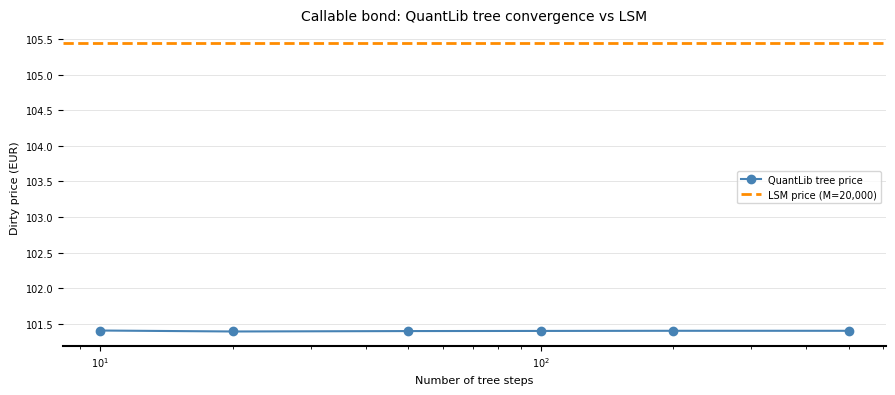

QuantLib converged price (500 steps): 101.4038
LSM best estimate (M=20,000):      105.4454
Difference: 4.0416 EUR


In [12]:
# ── QuantLib tree price vs number of tree steps ───────────────────────────────
# The tree should converge as number of steps increases
tree_steps = [10, 20, 50, 100, 200, 500]
ql_prices  = []
for n_tree in tree_steps:
    eng = ql.TreeCallableFixedRateBondEngine(hw_model, n_tree)
    ql_callable.setPricingEngine(eng)
    ql_prices.append(ql_callable.dirtyPrice())

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tree_steps, ql_prices, 'o-', color='steelblue', lw=1.5, ms=6,
            label="QuantLib tree price")
ax.axhline(lsm_best, lw=2.0, color='darkorange', ls='--',
           label=f"LSM price (M={M_best:,})")
ax.set_xlabel("Number of tree steps")
ax.set_ylabel("Dirty price (EUR)")
ax.set_title("Callable bond: QuantLib tree convergence vs LSM")
ax.legend()
plt.tight_layout()
plt.show()

print(f"QuantLib converged price (500 steps): {ql_prices[-1]:.4f}")
print(f"LSM best estimate (M={M_best:,}):      {lsm_best:.4f}")
print(f"Difference: {abs(ql_prices[-1] - lsm_best):.4f} EUR")

---
## Summary

### LSM vs Binomial Tree
<small>

| | Binomial/Trinomial Tree | Longstaff-Schwartz MC |
|---|---|---|
| Accuracy | High (exact in limit) | Slightly biased (regression error) |
| Convergence | $O(1/n_{\text{steps}})$ | $O(1/\sqrt{M})$ + regression bias |
| Scalability to portfolio | Poor — one tree per instrument | Excellent — reuse paths across instruments |
| Multi-factor extension | Exponential cost | Linear cost (add dimensions to regression) |
| Use in XVA | Impractical | Standard — simulate thousands of paths |

</small>

### Key implementation notes

1. **Backwards induction** — the call decision at $t_k$ depends on the value at $t_{k+1}$, which itself incorporates all later call decisions. Working backwards ensures consistency.
2. **Regression on ITM paths only** — paths where calling is not beneficial ($C \leq K$) are trivially "continue"; including them in the regression adds noise without information.
3. **Degree 2 polynomial is sufficient** for one-factor short rate models — the exercise boundary is a smooth function of $r$, well-approximated by a parabola.
4. **Antithetic variates** reduce standard error without changing the regression procedure — the exercise decision on antithetic paths is independent.
5. **LSM price is a lower bound** — the regression-based exercise policy is suboptimal, so the LSM price is slightly below the true option-adjusted price. More paths and richer basis reduce this gap.

### Negative convexity and IRRBB

The price-rate chart confirms **negative convexity**: the callable bond's price is capped near the call price as rates fall, while the straight bond continues to appreciate. Under the EBA/RTS/2022/10 parallel-down shock of $-200$bp, a bank holding callable bonds will see a smaller EVE gain than a straight bond would imply — the repricing schedule shortens as the embedded option comes into the money. The LSM framework provides the simulation-based valuation needed to capture this effect accurately.

---

**Next:** QRE-50 — MC equity paths — GBM, local volatility, and calibration to the volatility surface.